#### PRACTICE QUESTION - 5

Total Revenue:
 Category
High      1378269
Low        436461
Medium    1274120
Name: Revenue, dtype: int32

Average Quantity:
 Category
High      8.531707
Low       3.422062
Medium    6.134921
Name: Quantity, dtype: float64

Top 5 Transactions:
      Price  Quantity  Revenue Category
457    998        10     9980     High
479    965        10     9650     High
567    963        10     9630     High
739    960        10     9600     High
371    932        10     9320     High


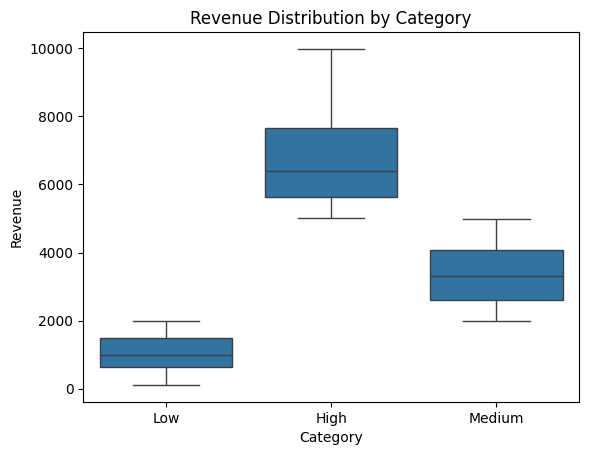

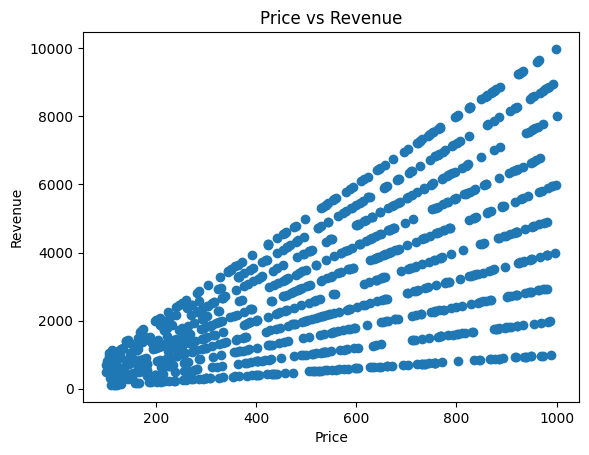

In [18]:
# You are analyzing sales data of an online store.
# Use NumPy to generate:
# 1000 random product prices (100 to 1000)
# 1000 random quantities sold (1 to 10)
# Create a Pandas DataFrame with:
# "Price"
# "Quantity"
# Create a new column:
# "Revenue" = Price × Quantity
# Create another column "Category":
# Revenue ≥ 5000 → "High"
# Revenue 2000–4999 → "Medium"
# Revenue < 2000 → "Low"
# Find:
# Total revenue per category
# Average quantity per category
# Top 5 highest revenue transactions
# Visualization:
# Seaborn: Box plot of Revenue by Category
# Matplotlib: Scatter plot of Price vs Revenue

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

prices = np.random.randint(100, 1001, 1000)
quantities = np.random.randint(1, 11, 1000)

df = pd.DataFrame({
    "Price": prices,
    "Quantity": quantities
})

df["Revenue"] = df["Price"] * df["Quantity"]

# Step 4: Categorization
def categorize(rev):
    if rev >= 5000:
        return "High"
    elif rev >= 2000:
        return "Medium"
    else:
        return "Low"

df["Category"] = df["Revenue"].apply(categorize)

total_revenue = df.groupby("Category")["Revenue"].sum()
avg_quantity = df.groupby("Category")["Quantity"].mean()
top5 = df.nlargest(5, "Revenue")

print("Total Revenue:\n", total_revenue)
print("\nAverage Quantity:\n", avg_quantity)
print("\nTop 5 Transactions:\n", top5)

sns.boxplot(x="Category", y="Revenue", data=df)
plt.title("Revenue Distribution by Category")
plt.show()

plt.scatter(df["Price"], df["Revenue"])
plt.title("Price vs Revenue")
plt.xlabel("Price")
plt.ylabel("Revenue")
plt.show()

#### PRACTICE QUESTION - 6

Top Customers:
 Customer_ID
33    40393.4
90    38810.4
62    33181.6
Name: Revenue, dtype: float64

Category Avg Revenue:
 Category
Clothing       1967.371839
Electronics    1462.207092
Home           1977.471892
Name: Revenue, dtype: float64

Special Customers:
 Series([], Name: Revenue, dtype: float64)

Outliers:
      Order_ID  Customer_ID  Product_ID  Quantity  Price     Category  Revenue
36         37           15           6       5.0  991.0         Home   4955.0
43         44           64           6       5.0  991.0         Home   4955.0
80         81           90          23       5.0  986.0  Electronics   4930.0
108       109           89          12       5.0  857.0     Clothing   4285.0
154       155           90           6       5.0  991.0         Home   4955.0


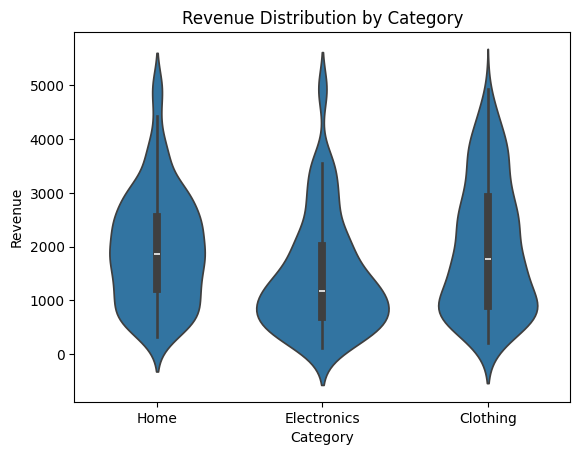

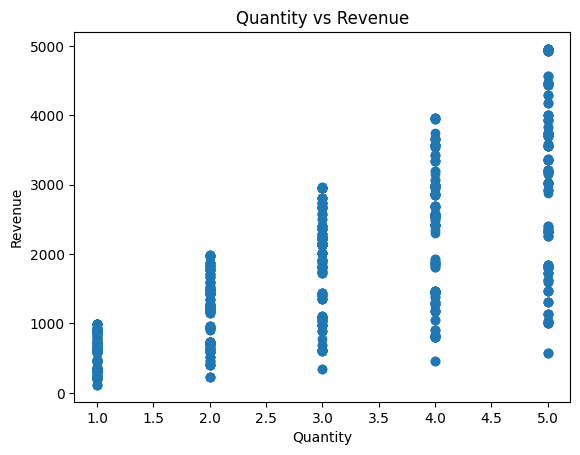

In [17]:
#PRACTICE QUESTION - 6
# You are given two datasets of an e-commerce platform:
# Dataset 1: Orders
# Generate using NumPy (1000 rows):
# "Order_ID" → 1 to 1000
# "Customer_ID" → random (1 to 100)
# "Product_ID" → random (1 to 50)
# "Quantity" → random (1 to 5), but include some missing values
#  Dataset 2: Products
# Generate:
# "Product_ID" → 1 to 50
# "Price" → random (100 to 1000), include some missing values
# "Category" → randomly assign: "Electronics", "Clothing", "Home"
# Tasks:
# 1. Data Cleaning
# Fill missing Quantity with median
# Fill missing Price with mean
# 2. Merge Datasets
# Combine Orders + Products using "Product_ID"
# 3. Feature Engineering
# Create "Revenue" = Price × Quantity
# 4. Advanced Logic (LeetCode Style )
# Find:
# Top 3 customers by total revenue
# Category with highest average revenue
# Customers who made only 1 order but spent > 3000
# Detect outliers in Revenue (very high values)
# 5. Visualization
# Seaborn:
# Violin plot of Revenue by Category
# Matplotlib:
# Scatter plot: Quantity vs Revenue

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

np.random.seed(42)

orders = pd.DataFrame({
    "Order_ID": np.arange(1, 1001),
    "Customer_ID": np.random.randint(1, 101, 1000),
    "Product_ID": np.random.randint(1, 51, 1000),
    "Quantity": np.random.randint(1, 6, 1000).astype(float)
})

orders.loc[np.random.choice(orders.index, 50), "Quantity"] = np.nan

products = pd.DataFrame({
    "Product_ID": np.arange(1, 51),
    "Price": np.random.randint(100, 1001, 50).astype(float),
    "Category": np.random.choice(["Electronics", "Clothing", "Home"], 50)
})

products.loc[np.random.choice(products.index, 5), "Price"] = np.nan

orders["Quantity"] = orders["Quantity"].fillna(orders["Quantity"].median())
products["Price"] = products["Price"].fillna(products["Price"].mean())

df = pd.merge(orders, products, on="Product_ID")

df["Revenue"] = df["Price"] * df["Quantity"]

top_customers = df.groupby("Customer_ID")["Revenue"].sum().nlargest(3)

category_avg = df.groupby("Category")["Revenue"].mean()

customer_orders = df.groupby("Customer_ID").size()
customer_revenue = df.groupby("Customer_ID")["Revenue"].sum()

special_customers = customer_revenue[
    (customer_orders == 1) & (customer_revenue > 3000)
]

threshold = df["Revenue"].mean() + 2 * df["Revenue"].std()
outliers = df[df["Revenue"] > threshold]

print("Top Customers:\n", top_customers)
print("\nCategory Avg Revenue:\n", category_avg)
print("\nSpecial Customers:\n", special_customers)
print("\nOutliers:\n", outliers.head())

sns.violinplot(x="Category", y="Revenue", data=df)
plt.title("Revenue Distribution by Category")
plt.show()

plt.scatter(df["Quantity"], df["Revenue"])
plt.xlabel("Quantity")
plt.ylabel("Revenue")
plt.title("Quantity vs Revenue")
plt.show()


#### PRACTICE QUESTION - 7

Top Growth Days:
           Date       Growth
2   2023-01-03  1376.231183
141 2023-05-22  1090.715525
358 2023-12-25   919.602674
725 2024-12-26   821.042654
79  2023-03-21   746.428571

Longest Increasing Streak: 4

Special Days:
          Date   Sales  Customers  Revenue_per_Customer     7_day_MA  \
9  2023-01-10  9322.0        412             22.626214  6140.285714   
12 2023-01-13  7949.0        343             23.174927  5027.857143   
14 2023-01-15  6311.0        420             15.026190  5435.285714   
16 2023-01-17  7420.0        241             30.788382  5088.285714   
20 2023-01-21  7396.0         88             84.045455  5614.571429   

        Growth  streak_group  
9    41.714807             4  
12  349.349915             6  
14   83.833382             7  
16   22.624360             8  
20   68.665906            10  


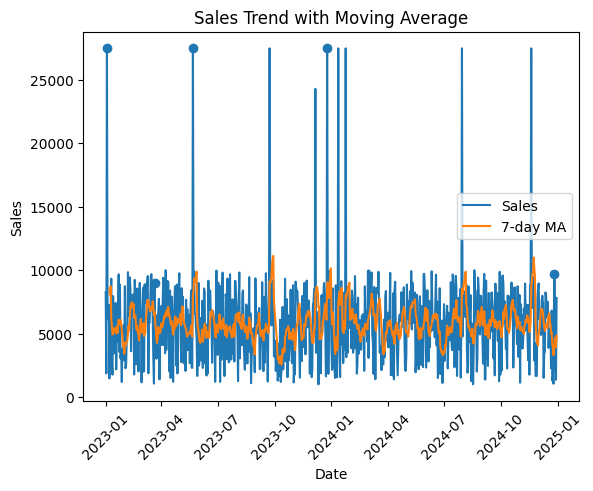

In [15]:
# Time-Series Sales Analysis
# You are given daily sales data of an online platform for 2 years (730 days).
# Tasks
# 1. Data Generation (NumPy)
# Create dataset with:
# "Date" → daily dates
# "Sales" → random (1000 to 10000)
# "Customers" → random (50 to 500)
# Add:
# Some missing values in Sales
# Some extreme spikes (outliers)
# 2. Data Cleaning
# Fill missing Sales using forward fill
# Handle outliers using clipping (limit values)
# 3. Feature Engineering
# Create:
# "Revenue_per_Customer" = Sales / Customers
# "7_day_MA" → 7-day moving average of Sales
# "Growth" → % change in Sales
# 4. Advanced Logic (Interview Level)
# Find:
# Top 5 days with highest growth spike
# Longest streak of increasing sales days
# Days where:
# Sales > 7-day average
# AND Growth > 10%
# 5. Visualization
# Seaborn:
# Lineplot of Sales + Moving Average
# Matplotlib:
# Highlight spike days on graph

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

np.random.seed(42)

dates = pd.date_range(start="2023-01-01", periods=730)

df = pd.DataFrame({
    "Date": dates,
    "Sales": np.random.randint(1000, 10000, 730).astype(float),
    "Customers": np.random.randint(50, 500, 730)
})

df.loc[np.random.choice(df.index, 20), "Sales"] = np.nan

df.loc[np.random.choice(df.index, 10), "Sales"] *= 5

df["Sales"] = df["Sales"].ffill()

upper_limit = df["Sales"].quantile(0.99)
df["Sales"] = df["Sales"].clip(upper=upper_limit)

df["Revenue_per_Customer"] = df["Sales"] / df["Customers"]

df["7_day_MA"] = df["Sales"].rolling(window=7).mean()

df["Growth"] = df["Sales"].pct_change() * 100


top_growth = df.nlargest(5, "Growth")

streak = (df["Sales"].diff() > 0).astype(int)
df["streak_group"] = (streak == 0).cumsum()
longest_streak = streak.groupby(df["streak_group"]).sum().max()

special_days = df[
    (df["Sales"] > df["7_day_MA"]) &
    (df["Growth"] > 10)
]

print("Top Growth Days:\n", top_growth[["Date", "Growth"]])
print("\nLongest Increasing Streak:", longest_streak)
print("\nSpecial Days:\n", special_days.head())

sns.lineplot(x="Date", y="Sales", data=df, label="Sales")
sns.lineplot(x="Date", y="7_day_MA", data=df, label="7-day MA")

plt.scatter(top_growth["Date"], top_growth["Sales"])

plt.title("Sales Trend with Moving Average")
plt.xticks(rotation=45)
plt.show()


#### PRACTICE QUESTION - 8

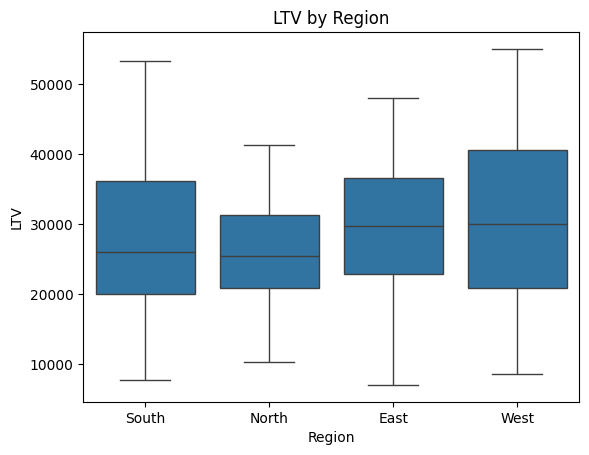

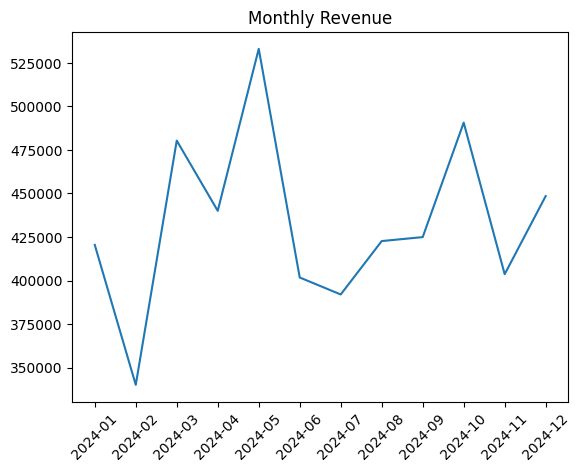

In [13]:
# User Retention & Revenue Analysis
# You are analyzing a platform like Amazon / Flipkart.
# Dataset 1: Transactions (generate with NumPy)
# Create 2000 rows:
# "User_ID" → random (1–200)
# "Date" → random dates within 1 year
# "Amount" → random (100–5000)
# Add:
# Some missing Amount values
# Some duplicate rows
# Dataset 2: Users
# "User_ID" → 1–200
# "Join_Date" → random past dates
# "Region" → "North", "South", "East", "West"
# Tasks
# 1. Data Cleaning
# Remove duplicates
# Fill missing Amount using median per user (tricky)
# 2. Merge
# Combine transactions + users
# 3. Feature Engineering
# Create:
# "Days_Since_Join" = Transaction Date - Join Date
# "Month" from Date
# "User_Lifetime_Value (LTV)" = total spend per user
# 4.Advanced Logic (FAANG Level)
# 🔹 A. Retention Problem
# Find:
# Users who made more than 1 purchase in different months
# (Real retention definition)
# B. Top Users Per Region
# Find top 2 users per region by LTV
# (Window function logic)
# C. Churn Risk Users
# Find users who:
# Have not purchased in the last 90 days
# But had LTV > 10000
# D. Edge Case Logic
# Find:
# Users whose first purchase amount > average purchase of that user
# (VERY tricky — think carefully)
# 5. Visualization
# Seaborn
# Boxplot: LTV by Region
# Matplotlib
# Line plot: Monthly total revenue

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

np.random.seed(42)

dates = pd.date_range("2024-01-01", periods=365)

transactions = pd.DataFrame({
    "User_ID": np.random.randint(1, 201, 2000),
    "Date": np.random.choice(dates, 2000),
    "Amount": np.random.randint(100, 5001, 2000).astype(float)
})

transactions.loc[np.random.choice(transactions.index, 50), "Amount"] = np.nan

transactions = pd.concat([transactions, transactions.iloc[:50]])

users = pd.DataFrame({
    "User_ID": np.arange(1, 201),
    "Join_Date": np.random.choice(dates, 200),
    "Region": np.random.choice(["North", "South", "East", "West"], 200)
})

transactions = transactions.drop_duplicates()

transactions["Amount"] = transactions.groupby("User_ID")["Amount"]\
    .transform(lambda x: x.fillna(x.median()))

df = pd.merge(transactions, users, on="User_ID")

df["Days_Since_Join"] = (df["Date"] - df["Join_Date"]).dt.days
df["Month"] = df["Date"].dt.to_period("M")

df["LTV"] = df.groupby("User_ID")["Amount"].transform("sum")

user_months = df.groupby("User_ID")["Month"].nunique()
retained_users = user_months[user_months > 1]

df["Rank"] = df.groupby("Region")["LTV"]\
    .rank(method="first", ascending=False)

top_users = df[df["Rank"] <= 2]

last_date = df["Date"].max()

last_purchase = df.groupby("User_ID")["Date"].max()

churn_users = last_purchase[
    (last_date - last_purchase > pd.Timedelta(days=90))
    ]

high_value = df.groupby("User_ID")["Amount"].sum()
churn_risk = churn_users.index.intersection(
    high_value[high_value > 10000].index
)

avg_amount = df.groupby("User_ID")["Amount"].transform("mean")

first_purchase = df.sort_values("Date").groupby("User_ID").first()

edge_case_users = first_purchase[
    first_purchase["Amount"] > avg_amount.groupby(df["User_ID"]).first()
]


sns.boxplot(x="Region", y="LTV", data=df)
plt.title("LTV by Region")
plt.show()

monthly_revenue = df.groupby("Month")["Amount"].sum()

plt.plot(monthly_revenue.index.astype(str), monthly_revenue.values)
plt.xticks(rotation=45)
plt.title("Monthly Revenue")
plt.show()